# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [1]:
import os

import torch
import datasets
import lightning.pytorch as pl
import tokenizers
from typing import *
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt

# Data

In [3]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        ds_path: str,
        bs: int = 16,
        num_workers: int = 12,
        vocab_size: int = 5000,
        max_length: int = 256
    ):
        super().__init__()
        self.bs = bs
        
        ds = self.load_and_process_ds(ds_path)
        ds_train, ds_val, ds_test = self.train_val_test_split(ds)
        self.ds = datasets.DatasetDict({"train": ds_train, "val": ds_val, "test": ds_test})

        tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram(vocab = [("[UNK]", 0)], unk_id = 0))
        trainer = tokenizers.trainers.UnigramTrainer(vocab_size=vocab_size, unk_token = "[UNK]", special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])
        tokenizer.train_from_iterator(self.ds['train']['ttext'], trainer=trainer)

        tokenizer.enable_truncation(max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        self.tokenizer = tokenizer

    def train_dataloader(self) -> torch.utils.data.DataLoader:
        return self.dataloader("train", True)

    def val_dataloader(self) -> torch.utils.data.DataLoader:
        return self.dataloader("val", True)

    def test_dataloader(self) -> torch.utils.data.DataLoader:
        return self.dataloader("test", False)
    
    def encode(self, batch) -> Dict:
        encodings = self.tokenizer.encode_batch([element["ttext"] for element in batch])
        input_ids = torch.tensor([element.ids for element in encodings])
        labels = torch.tensor([element["ttype"] if element["ttype"] == 1 else 0 for element in batch])
        return {"input_ids": input_ids, "label": labels}

    def dataloader(self, split_name, need_shuffle):
        return torch.utils.data.DataLoader(self.ds[split_name], batch_size = self.bs, shuffle = need_shuffle, collate_fn = self.encode)
    
    def load_and_process_ds(self, data_dir):
        negative_file = os.path.join(data_dir, "negative.csv")
        positive_file = os.path.join(data_dir, "positive.csv")
        header_names = ["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount']
        negative_df = pd.read_csv(negative_file, delimiter = ";", header = None, names = header_names).sample(5000, random_state = 42)
        positive_df = pd.read_csv(positive_file, delimiter = ";", header = None, names = header_names).sample(5000, random_state = 42)
        return datasets.Dataset.from_pandas(pd.concat([negative_df, positive_df]))
    
    def train_val_test_split(self, ds):
        train_test__val = ds.train_test_split(test_size = 0.2)
        train__test = train_test__val["train"].train_test_split(test_size = 0.25)
        return train__test["train"], train_test__val["test"], train__test["test"]

# Model

In [4]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.output_size = output_size
        
        self.embedding = torch.nn.Embedding(vocab_size, embd_size)
        self.rnn = torch.nn.RNN(embd_size, hidden_size, batch_first = True)
        self.fc = torch.nn.Linear(hidden_size, output_size)
        
        self.loss = torch.nn.CrossEntropyLoss()
    
    def configure_model(self):
            self.metrics = {
                split: torchmetrics.F1Score(
                    task="multiclass", num_classes=self.output_size
                ) 
                for split in ["train", "val", "test"]
            }

    def forward(self, x):
        out = self.embedding(x)
        _, out = self.rnn(out)
        out = self.fc(out)
        return out
    
    def training_step(self, batch, batch_idx):
        return self.step(batch, "train")
    
    def validation_step(self, batch, batch_idx):
        return self.step(batch, "val")
    
    def test_step(self, batch, batch_idx):
        return self.step(batch, "test")
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)
    
    def step(self, batch, split_name):
        preds = self(batch["input_ids"])[0]
        targets = batch["label"]
        loss = self.loss(preds, targets)
        metrics = self.metrics[split_name](preds, targets)
        self.log(f"{split_name}_loss", loss, on_step = False, on_epoch = True)
        self.log(f"{split_name}_metrics", metrics, on_step = False, on_epoch = True)
        return loss


# Trainer

In [34]:
vocab_sizes = [1000, 2000, 3000, 4000, 4500, 5000, 5500, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
max_length = 256
embd_size = 256
hidden_size = 256

logs_folder = "logs"

for vocab_size in vocab_sizes:
    dm = MyDataModule("../Data", vocab_size=vocab_size, max_length=max_length)
    model = RNNModel(vocab_size=vocab_size, embd_size=embd_size, hidden_size=hidden_size, output_size=2)

    logger = pl.loggers.CSVLogger(logs_folder, version = vocab_size)
    trainer = pl.Trainer(logger = logger, max_epochs=10)
    trainer.fit(model=model, datamodule=dm)
    trainer.test(datamodule=dm, ckpt_path="best")

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory logs\lightning_logs\version_1000 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory logs\lightning_logs\version_1000\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | embedding | Embedding        | 256 K  | train
1 | rnn       | RNN            

Sanity Checking: |                                                                               | 0/? [00:00<…

c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=10` reached.
Restoring states from the checkpoint path at logs\lightning_logs\version_12000\checkpoints\epoch=9-step=3750-v1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\lightning_logs\version_12000\checkpoints\epoch=9-step=3750-v1.ckpt
c:\users\den26\appdata\local\programs\python\python39\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     0.476967453956604     │
│       test_metrics        │    0.8859999775886536     │
└───────────────────────────┴───────────────────────────┘

In [35]:
test_metrics = []
for vocab_size in vocab_sizes:
    metrics = pd.read_csv(f"{logs_folder}/lightning_logs/version_{vocab_size}/metrics.csv")
    test_metrics.append(metrics["test_metrics"].dropna().iloc[0])

[]

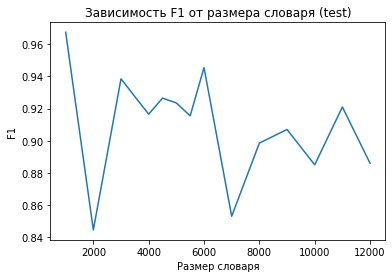

In [36]:
plt.plot(vocab_sizes, test_metrics)
plt.title("Зависимость F1 от размера словаря (test)")
plt.xlabel("Размер словаря")
plt.ylabel("F1")
plt.plot()

In [1]:
import pandas as pd

In [4]:
vocab_sizes = [1000, 2000, 3000, 4000, 4500, 5000, 5500, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
max_length = 256
embd_size = 256
hidden_size = 256

logs_folder = "logs"
test_metrics = []
for vocab_size in vocab_sizes:
    metrics = pd.read_csv(f"{logs_folder}/lightning_logs/version_{vocab_size}/metrics.csv")
    test_metrics.append(metrics["test_metrics"].dropna().iloc[0])

In [5]:
test_metrics

[0.9674999713897704,
 0.8445000052452087,
 0.9384999871253968,
 0.9164999723434448,
 0.9265000224113464,
 0.9235000014305116,
 0.915499985218048,
 0.9455000162124634,
 0.8529999852180481,
 0.8985000252723694,
 0.9070000052452089,
 0.8849999904632568,
 0.9210000038146972,
 0.8859999775886536]